<a href="https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/meteoc_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Training Session — CoMet Toolkit: Uncertainties Made Easy**

# Exercise: From Spectrometer Measurements to NDVI with Uncertainty Propagation

## Overview

This exercise demonstrates how to propagate uncertainties through a complete measurement workflow, from raw spectrometer data to a vegetation index (NDVI).

In a lab session, repeated spectrometer measurements were taken for three surface targets:
- **Astro turf**
- **Cress**
- **Sand**
- **Spectralon reference panel** (for calibration)

All targets were illuminated using the same lamp. The Spectralon panel, with its known reflectance spectrum, enables conversion from raw digital numbers (DN) to calibrated surface reflectance:

$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

## Learning Objectives

By the end of this exercise, you will be able to:
- Define a measurement model in Python
- Estimate random uncertainty from repeated measurements
- Include systematic uncertainty from reference standards
- Use **punpy** to propagate uncertainty through multi-step calculations
- Perform spectral band integration using sensors' response functions
- Calculate NDVI (Normalized Difference Vegetation Index) with uncertainty propagation
- Compare results across different surface materials

## *Step 1* - Set up the Environment

First, install the required packages for uncertainty propagation and band integration:

In [ ]:
!pip install punpy>=1.0.6 matheo

**If running in Google Colab:** Click `Runtime > Restart session` above to load the newly installed packages.  
**If running locally:** The kernel will use the packages automatically after installation.

Then import the required python packages:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import punpy
import xarray as xr
from matheo import band_integration

❗ **Note:** If any imports fail, restart the kernel/session and try again.

## *Step 2* - Load and Inspect the Measurement Data

### Data Description

The dataset contains repeated spectrometer measurements from 600–1000 nm for:
- **Spectralon** (for calibration purposes)
- **Astro turf** (25–75 repeats per target)
- **Cress** (25–75 repeats per target)
- **Sand** (25–75 repeats per target)

In [ ]:
!git clone https://github.com/comet-toolkit/comet_training.git

fatal: destination path 'comet_training' already exists and is not an empty directory.


In [ ]:
# Load datasets from NetCDF files
spectralon_ds = xr.load_dataset("example_data/Spectralon.nc")
astroturf_ds = xr.load_dataset("example_data/Astro_turf.nc")
cress_ds = xr.load_dataset("example_data/Cress.nc")
sand_ds = xr.load_dataset("example_data/Sand.nc")

# Load Spectralon reference reflectance
spectralon_ref_ds = xr.load_dataset("example_data/spectralon_reflectance.nc")

# Extract wavelengths and digital number (DN) data
wavelength = spectralon_ds['wavelength'].values

dn_panel_repeats = spectralon_ds['digital_number'].values / spectralon_ds.attrs['integration_time_ms']      # shape: (n_wavelength, n_panel_repeats)
dn_astroturf_repeats = astroturf_ds['digital_number'].values / astroturf_ds.attrs['integration_time_ms']     # shape: (n_wavelength, n_astroturf_repeats)
dn_cress_repeats = cress_ds['digital_number'].values / cress_ds.attrs['integration_time_ms']             # shape: (n_wavelength, n_cress_repeats)
dn_sand_repeats = sand_ds['digital_number'].values / sand_ds.attrs['integration_time_ms']               # shape: (n_wavelength, n_sand_repeats)

# Load and interpolate Spectralon reflectance to measured wavelength grid
from scipy import interpolate

wavelength_ref = spectralon_ref_ds['wavelength'].values
reflectance_ref = spectralon_ref_ds['reflectance'].values

# Create linear interpolation function
f_interp = interpolate.interp1d(wavelength_ref, reflectance_ref, kind='linear', 
                                bounds_error=False, fill_value='extrapolate')

# Interpolate to measured wavelength grid
rho_panel = f_interp(wavelength)

# Create wavelength-dependent uncertainty for Spectralon reflectance (in %)
# Based on calibration certificate data
u_rho_panel_percent = np.zeros_like(wavelength)
u_rho_panel_percent[(wavelength >= 380) & (wavelength < 405)] = 1.55
u_rho_panel_percent[(wavelength >= 405) & (wavelength < 465)] = 0.60
u_rho_panel_percent[(wavelength >= 465) & (wavelength <= 780)] = 0.55
u_rho_panel_percent[(wavelength > 780) & (wavelength <= 900)] = 1.60

# Convert uncertainty from percentage to absolute value
u_rho_panel = (u_rho_panel_percent / 100.0) * rho_panel

print("Wavelength shape:", wavelength.shape)
print("Panel repeats:", dn_panel_repeats.shape)
print("Astro-turf repeats:", dn_astroturf_repeats.shape)
print("Cress repeats:", dn_cress_repeats.shape)
print("Sand repeats:", dn_sand_repeats.shape)
print(f"\nSpectralon reflectance loaded:")
print(f"  Reference wavelength range: {wavelength_ref.min():.1f} - {wavelength_ref.max():.1f} nm")
print(f"  Interpolated to measured range: {wavelength.min():.2f} - {wavelength.max():.2f} nm")
print(f"  Panel reflectance range: {rho_panel.min():.4f} - {rho_panel.max():.4f}")
print(f"\nWavelength-dependent uncertainties:")
print(f"  380–405 nm:   1.55%")
print(f"  405–465 nm:   0.60%")
print(f"  465–780 nm:   0.55%")
print(f"  780–900 nm:   1.60%")
print(f"  Absolute uncertainty range: {u_rho_panel.min():.6f} - {u_rho_panel.max():.6f}")

Wavelength shape: (1718,)
Panel repeats: (1718, 25)
Astro-turf repeats: (1718, 51)
Cress repeats: (1718, 77)
Sand repeats: (1718, 60)

Spectralon reflectance loaded:
  Reference wavelength range: 380.0 - 1000.0 nm
  Interpolated to measured range: 600.01 - 999.85 nm
  Panel reflectance range: 0.9942 - 0.9950

Wavelength-dependent uncertainties:
  380–405 nm:   1.55%
  405–465 nm:   0.60%
  465–780 nm:   0.55%
  780–900 nm:   1.60%
  Absolute uncertainty range: 0.000000 - 0.015917


### Inspect the repeated measurements
First, calculate the mean and standard deviation of the repeated DN measurements for each target.
The standard deviation of repeated measurements will be used to estimate the random measurement noise.

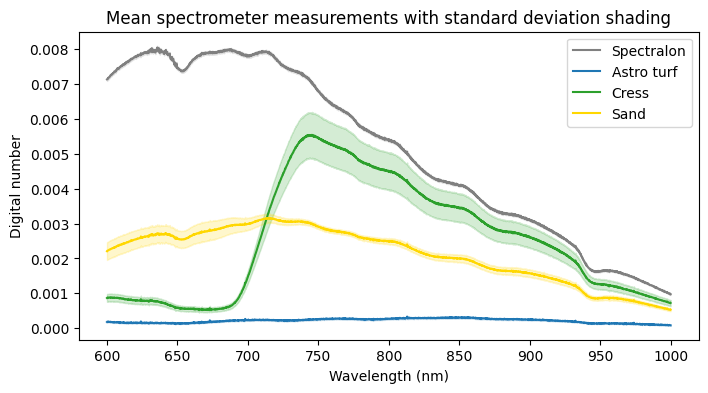

In [ ]:
def calculate_stats(dn_repeats):
    """
    Calculate mean and standard deviation across repeated measurements.

    :param dn_repeats: repeated measurements array (shape: n_wavelengths × n_repeats)
    :returns: tuple of (mean, standard_deviation) arrays
    """
    mean = np.mean(dn_repeats, axis=1)
    std = np.std(dn_repeats, axis=1, ddof=1)
    return mean, std

# Calculate mean and std for each target
dn_panel_mean, dn_panel_std = calculate_stats(dn_panel_repeats)
dn_astroturf_mean, dn_astroturf_std = calculate_stats(dn_astroturf_repeats)
dn_cress_mean, dn_cress_std = calculate_stats(dn_cress_repeats)
dn_sand_mean, dn_sand_std = calculate_stats(dn_sand_repeats)

# Define consistent colors for surfaces (used throughout the notebook)
color_map = {"Spectralon": "gray", "Astro turf": "tab:blue", "Cress": "tab:green", "Sand": "gold"}

# Plot the DN measurement data with shaded uncertainty regions
plt.figure(figsize=(8, 4))
plt.plot(wavelength, dn_panel_mean, label="Spectralon", linewidth=1.5, color=color_map["Spectralon"])
plt.fill_between(wavelength, dn_panel_mean - dn_panel_std, dn_panel_mean + dn_panel_std, alpha=0.2, color=color_map["Spectralon"])

plt.plot(wavelength, dn_astroturf_mean, label="Astro turf", linewidth=1.5, color=color_map["Astro turf"])
plt.fill_between(wavelength, dn_astroturf_mean - dn_astroturf_std, dn_astroturf_mean + dn_astroturf_std, alpha=0.2, color=color_map["Astro turf"])

plt.plot(wavelength, dn_cress_mean, label="Cress", linewidth=1.5, color=color_map["Cress"])
plt.fill_between(wavelength, dn_cress_mean - dn_cress_std, dn_cress_mean + dn_cress_std, alpha=0.2, color=color_map["Cress"])

plt.plot(wavelength, dn_sand_mean, label="Sand", linewidth=1.5, color=color_map["Sand"])
plt.fill_between(wavelength, dn_sand_mean - dn_sand_std, dn_sand_mean + dn_sand_std, alpha=0.2, color=color_map["Sand"])

plt.xlabel("Wavelength (nm)")
plt.ylabel("Digital number")
plt.title("Mean spectrometer measurements with standard deviation shading")
plt.legend()
plt.show()

### Understanding the Uncertainty Sources

This exercise considers two main categories of uncertainty:

**Random uncertainty:** Arises from measurement repeatability
- Variation in DN measurements for each surface
- Variation in DN measurements for the Spectralon panel

**Systematic uncertainty:** Arises from calibration standards
- Uncertainty in the Spectralon panel's reflectance spectrum

These uncertainties will propagate through each calculation step: reflectance calibration → band integration → NDVI calculation.

## *Step 3* - Define the Measurement Functions

Now we implement the three measurement models that will be used to transform raw DN measurements into a final NDVI value with uncertainties.

### Measurement Models

We use three mathematical models in this analysis:

**1. Surface Reflectance** (from DN measurements and panel calibration):
$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

**2. Band-Integrated Reflectance** (from full spectrum to red and NIR bands):
$$\rho_{\text{band}} = \text{mean}(\rho(\lambda)) \quad \text{for } \lambda \in [\lambda_{\min}, \lambda_{\max}]$$
where we average reflectance over each band's wavelength range. (Advanced methods use spectral response functions, but this simplified approach is sufficient for this exercise.)

**3. Normalised NDVI** (from red and NIR reflectances):
$$\text{NDVI} = \frac{\rho_{\text{NIR}} - \rho_{\text{red}}}{\rho_{\text{NIR}} + \rho_{\text{red}}}$$

In [ ]:
def reflectance_model(dn_surface, dn_panel, rho_panel):
    """Calibrate surface reflectance from DN using reference panel."""
    return (dn_surface / dn_panel) * rho_panel

def simple_band_integrate(reflectance, wavelength, wl_min, wl_max):
    """Average reflectance over a wavelength range."""
    mask = (wavelength >= wl_min) & (wavelength <= wl_max)
    if np.sum(mask) == 0:
        return 0.0
    return np.mean(reflectance[mask])

def band_integrate_red(reflectance, wavelength):
    """Integrate reflectance to red band (630–690 nm)."""
    return simple_band_integrate(reflectance, wavelength, 630, 690)

def band_integrate_nir(reflectance, wavelength):
    """Integrate reflectance to NIR band (770–900 nm)."""
    return simple_band_integrate(reflectance, wavelength, 770, 900)

def band_integrate(reflectance, wavelength):
    """Integrate reflectance to red and NIR bands."""
    red = band_integrate_red(reflectance, wavelength)
    nir = band_integrate_nir(reflectance, wavelength)
    return red, nir

def ndvi_model(rho_red, rho_nir):
    """Calculate NDVI from red and NIR reflectances."""
    return (rho_nir - rho_red) / (rho_nir + rho_red)

## *Step 4* - Calculate Reflectance Spectra

Using the reflectance calibration model from Step 3, we now calculate the reflectance spectrum for each surface target.

In [ ]:
rho_astroturf = reflectance_model(dn_astroturf_mean, dn_panel_mean, rho_panel)
rho_cress = reflectance_model(dn_cress_mean, dn_panel_mean, rho_panel)
rho_sand = reflectance_model(dn_sand_mean, dn_panel_mean, rho_panel)

## *Step 5* - Propagate Uncertainties to Reflectance Spectra

With the reflectance spectra calculated, we now propagate the input uncertainties through the calibration model. This accounts for:
- **Random uncertainty** from repeated measurement noise (DN standard deviation for both surface and panel)
- **Systematic uncertainty** from the panel calibration certificate (wavelength-dependent)

We use **punpy**'s Monte Carlo approach to combine these independent uncertainty sources.

In [ ]:
# Create a punpy Monte Carlo propagation object with 10,000 iterations
prop = punpy.MCPropagation(10000)

# Propagate uncertainties through the reflectance model for each surface
# ASTROTURF
u_random_rho_astroturf = prop.propagate_random(
   reflectance_model,
   [dn_astroturf_mean, dn_panel_mean, rho_panel],
   [dn_astroturf_std, dn_panel_std, None]
)
u_syst_rho_astroturf = prop.propagate_systematic(
    reflectance_model,
        [dn_astroturf_mean, dn_panel_mean, rho_panel],
        [None, None, u_rho_panel]
)

# CRESS
u_random_rho_cress = prop.propagate_random(
   reflectance_model,
    [dn_cress_mean, dn_panel_mean, rho_panel],
    [dn_cress_std, dn_panel_std, None]
)
u_syst_rho_cress = prop.propagate_systematic(
    reflectance_model,
     [dn_cress_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

# SAND
u_random_rho_sand = prop.propagate_random(
   reflectance_model,
    [dn_sand_mean, dn_panel_mean, rho_panel],
    [dn_sand_std, dn_panel_std, None]
)
u_syst_rho_sand = prop.propagate_systematic(
    reflectance_model,
     [dn_sand_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

### Combining Uncertainties

Random and systematic uncertainties are independent error sources and should be combined in quadrature:

$$u_{\text{total}} = \sqrt{u_{\text{random}}^2 + u_{\text{systematic}}^2}$$

This gives the total combined uncertainty, which represents our best estimate of the measurement error from all sources.

In [ ]:
# Calculate total uncertainty by combining random and systematic components
u_rho_astroturf = np.sqrt(u_random_rho_astroturf**2 + u_syst_rho_astroturf**2)
u_rho_cress = np.sqrt(u_random_rho_cress**2 + u_syst_rho_cress**2)
u_rho_sand = np.sqrt(u_random_rho_sand**2 + u_syst_rho_sand**2)


# Print summary statistics of uncertainties for each target
surfaces = {
    "Astro turf": (u_random_rho_astroturf, u_syst_rho_astroturf),
    "Cress": (u_random_rho_cress, u_syst_rho_cress),
    "Sand": (u_random_rho_sand, u_syst_rho_sand)
}

for surface, (u_random, u_syst) in surfaces.items():
    u_total = np.sqrt(u_random**2 + u_syst**2)
    print(f"\n{surface}:")
    print(f"  Random uncertainty:     mean={u_random.mean():.4e}, min={u_random.min():.4e}, max={u_random.max():.4e}")
    print(f"  Systematic uncertainty: mean={u_syst.mean():.4e}, min={u_syst.min():.4e}, max={u_syst.max():.4e}")
    print(f"  Total uncertainty:      mean={u_total.mean():.4e}, min={u_total.min():.4e}, max={u_total.max():.4e}")


Astro turf:
  Random uncertainty:     mean=4.5434e-03, min=1.3968e-03, max=1.1764e-02
  Systematic uncertainty: mean=3.7976e-04, min=2.2204e-16, max=1.3011e-03
  Total uncertainty:      mean=4.5761e-03, min=1.4007e-03, max=1.1764e-02

Cress:
  Random uncertainty:     mean=7.0119e-02, min=8.0498e-03, max=1.0121e-01
  Systematic uncertainty: mean=4.8394e-03, min=1.1102e-16, max=1.3511e-02
  Total uncertainty:      mean=7.0408e-02, min=8.0586e-03, max=1.0209e-01

Sand:
  Random uncertainty:     mean=2.7232e-02, min=8.7803e-03, max=4.3766e-02
  Systematic uncertainty: mean=3.2660e-03, min=0.0000e+00, max=8.1988e-03
  Total uncertainty:      mean=2.7683e-02, min=9.0982e-03, max=4.3766e-02


### Visualizing Uncertainty Components

Now in Step 5, we'll examine how the uncertainties vary across the spectrum. This helps us understand:
- Which wavelength regions have the largest errors?
- Does measurement noise (random) or calibration uncertainty (systematic) dominate?
- How do the uncertainties differ between surfaces?

Let's define plotting functions to visualize these components clearly.

In [ ]:
# Define some helper functions to plot spectra with uncertainty
def plot_uncertainty_components(wavelength, u_random, u_syst, label, ax=None, percent=False, rho=None, ylim=None):
    """Plot random, systematic, and total uncertainty components."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
        show_plot = True
    else:
        show_plot = False

    if ylim is not None:
        ax.set_ylim(ylim)

    if percent:
        u_random = 100 * u_random / rho
        u_syst = 100 * u_syst / rho
    ax.plot(wavelength, u_random, label="Random uncertainty", linestyle='--', linewidth=0.5)
    ax.plot(wavelength, u_syst, label="Systematic uncertainty", linestyle='--', linewidth=0.7)
    ax.plot(wavelength, np.sqrt(u_random**2 + u_syst**2), label="Total uncertainty", linewidth=0.5)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Uncertainty in Reflectance (%)" if percent else "Uncertainty in Reflectance")
    ax.set_title(f"Uncertainty Components for {label}")
    ax.legend()
    if show_plot:
        plt.show()

def plot_spectrum_with_uncertainty(wavelength, rho, u_rho, label, ax=None, color='blue'):
    """Plot reflectance spectrum with ±1σ uncertainty band."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
        show_plot = True
    else:
        show_plot = False
   
    ax.plot(wavelength, rho, label=label, linewidth=2, color=color)
    ax.fill_between(wavelength, rho - u_rho, rho + u_rho, alpha=0.3, color=color)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance")
    ax.legend()
   
    if show_plot:
        ax.set_title(f"{label} reflectance with uncertainty")
        plt.show()


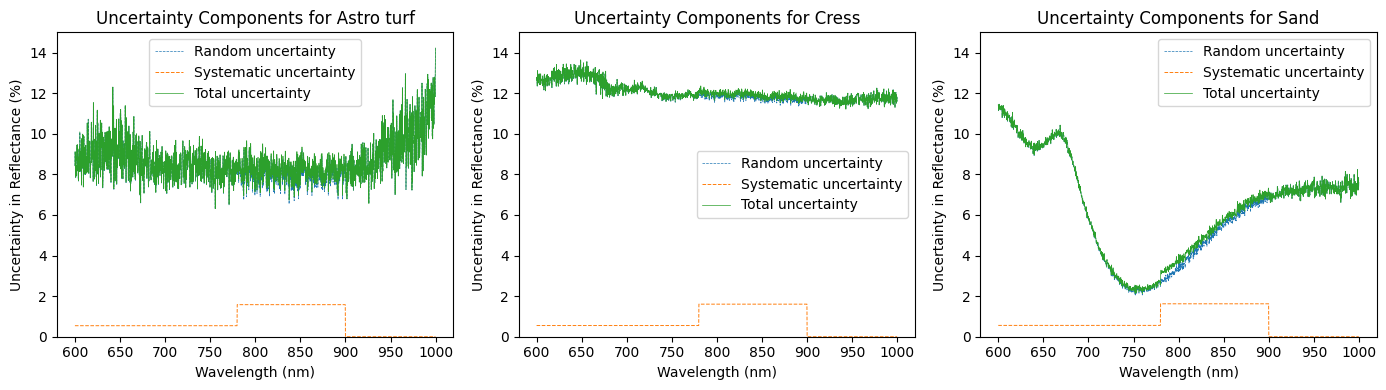

In [ ]:
# Plot uncertainty components for each target as subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_uncertainty_components(wavelength, u_random_rho_astroturf, u_syst_rho_astroturf, "Astro turf", ax=axes[0], percent=True, rho=rho_astroturf, ylim=(0, 15))
plot_uncertainty_components(wavelength, u_random_rho_cress, u_syst_rho_cress, "Cress", ax=axes[1], percent=True, rho=rho_cress, ylim=(0, 15))
plot_uncertainty_components(wavelength, u_random_rho_sand, u_syst_rho_sand, "Sand", ax=axes[2], percent=True, rho=rho_sand, ylim=(0, 15))
plt.tight_layout()
plt.show()

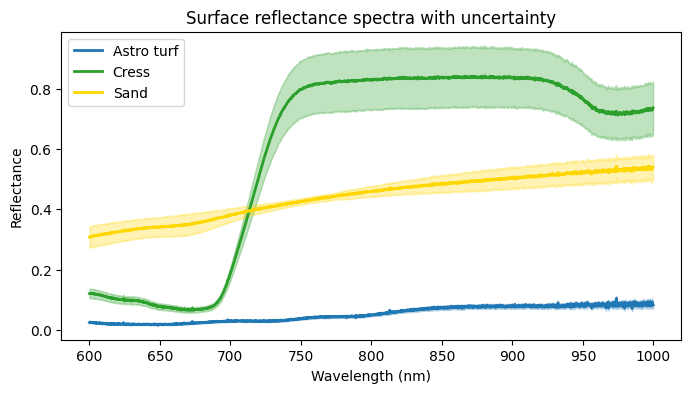

In [ ]:
# Plot spectra with uncertainty for each target
fig, ax = plt.subplots(figsize=(8, 4))
plot_spectrum_with_uncertainty(wavelength, rho_astroturf, u_rho_astroturf, "Astro turf", ax=ax, color=color_map["Astro turf"])
plot_spectrum_with_uncertainty(wavelength, rho_cress, u_rho_cress, "Cress", ax=ax, color=color_map["Cress"])
plot_spectrum_with_uncertainty(wavelength, rho_sand, u_rho_sand, "Sand", ax=ax, color=color_map["Sand"])
ax.set_title("Surface reflectance spectra with uncertainty")
plt.show()

## *Step 6* - Band Integration and Uncertainty Propagation

The full reflectance spectra (and their uncertainties) from Step 5 are now ready to be transformed into satellite-compatible data products. Satellite vegetation indices like NDVI are not computed from full spectra but from specific spectral bands. We now integrate our measured reflectance spectra to red and near-infrared bands, propagating the accumulated uncertainties through this aggregation step.

### Band Integration Approach

This exercise uses **simplified band integration**—averaging reflectance within each band's wavelength range:
- **Red band:** 630–690 nm
- **NIR band:** 770–900 nm

The uncertainties are also propagated through this averaging operation, so the final band reflectances carry forward the spectrum-level uncertainties.

In [ ]:
# Calculate band-integrated reflectances for each surface
# ASTROTURF
rho_astroturf_red, rho_astroturf_nir = band_integrate(rho_astroturf, wavelength)

# CRESS
rho_cress_red, rho_cress_nir = band_integrate(rho_cress, wavelength)

# SAND
rho_sand_red, rho_sand_nir = band_integrate(rho_sand, wavelength)

# Display results
print("Band-integrated reflectance values:")
print(f"\n  Astro turf:")
print(f"    Red  (630–690 nm):  {rho_astroturf_red:.4f}")
print(f"    NIR  (770–900 nm):  {rho_astroturf_nir:.4f}")
print(f"\n  Cress:")
print(f"    Red  (630–690 nm):  {rho_cress_red:.4f}")
print(f"    NIR  (770–900 nm):  {rho_cress_nir:.4f}")
print(f"\n  Sand:")
print(f"    Red  (630–690 nm):  {rho_sand_red:.4f}")
print(f"    NIR  (770–900 nm):  {rho_sand_nir:.4f}")

Band-integrated reflectance values:

  Astro turf:
    Red  (630–690 nm):  0.0208
    NIR  (770–900 nm):  0.0644

  Cress:
    Red  (630–690 nm):  0.0776
    NIR  (770–900 nm):  0.8335

  Sand:
    Red  (630–690 nm):  0.3473
    NIR  (770–900 nm):  0.4757


In [ ]:
# Propagate uncertainties through band integration for each surface and band

# ASTRO TURF
u_random_rho_astroturf_red, u_random_rho_astroturf_nir = prop.propagate_random(
    band_integrate, [rho_astroturf, wavelength],
    [u_random_rho_astroturf, None]
)

u_syst_rho_astroturf_red, u_syst_rho_astroturf_nir = prop.propagate_systematic(
    band_integrate, [rho_astroturf, wavelength],
    [u_syst_rho_astroturf, None]
)

# CRESS
u_random_rho_cress_red, u_random_rho_cress_nir = prop.propagate_random(
    band_integrate, [rho_cress, wavelength],
    [u_random_rho_cress, None]
)
u_syst_rho_cress_red, u_syst_rho_cress_nir = prop.propagate_systematic(
    band_integrate, [rho_cress, wavelength],
    [u_syst_rho_cress, None]
)

# SAND
u_random_rho_sand_red, u_random_rho_sand_nir = prop.propagate_random(
    band_integrate, [rho_sand, wavelength],
    [u_random_rho_sand, None]
)
u_syst_rho_sand_red, u_syst_rho_sand_nir = prop.propagate_systematic(
    band_integrate, [rho_sand, wavelength],
    [u_syst_rho_sand, None]
)

print("Total uncertainties propagated through band integration:")
print(f"\n  Red band:   Astro turf = {np.sqrt(u_random_rho_astroturf_red**2 + u_syst_rho_astroturf_red**2 )*100/rho_astroturf_red:.2f} %,  Cress = {np.sqrt(u_random_rho_cress_red**2 + u_syst_rho_cress_red**2 )*100/rho_cress_red:.2f} %,  Sand = {np.sqrt(u_random_rho_sand_red**2 + u_syst_rho_sand_red**2 )*100/rho_sand_red:.2f} %")
print(f"  NIR band:   Astro turf = {np.sqrt(u_random_rho_astroturf_nir**2 + u_syst_rho_astroturf_nir**2 )*100/rho_astroturf_nir:.2f} %,  Cress = {np.sqrt(u_random_rho_cress_nir**2 + u_syst_rho_cress_nir**2 )*100/rho_cress_nir:.2f} %,  Sand = {np.sqrt(u_random_rho_sand_nir**2 + u_syst_rho_sand_nir**2 )*100/rho_sand_nir:.2f} %")


Total uncertainties propagated through band integration:

  Red band:   Astro turf = 0.77 %,  Cress = 0.96 %,  Sand = 0.80 %
  NIR band:   Astro turf = 1.56 %,  Cress = 1.61 %,  Sand = 1.56 %


## *Step 7* - Calculate NDVI and Propagate Final Uncertainties

Now we compute the final NDVI value from the band-integrated red and NIR reflectances. The uncertainty in NDVI comes from the combined uncertainties in both bands, propagated through the NDVI formula.

This demonstrates the complete uncertainty chain: **DN noise + panel calibration → reflectance uncertainties → band uncertainties → NDVI uncertainties**.

In [ ]:
# Calculate NDVI for each target
ndvi_astroturf = ndvi_model(rho_astroturf_red, rho_astroturf_nir)
ndvi_cress = ndvi_model(rho_cress_red, rho_cress_nir)
ndvi_sand = ndvi_model(rho_sand_red, rho_sand_nir)

print(f"\nNDVI values:")
print(f"  Astro turf:  {ndvi_astroturf:.4f}")
print(f"  Cress:       {ndvi_cress:.4f}")
print(f"  Sand:        {ndvi_sand:.4f}")


NDVI values:
  Astro turf:  0.5112
  Cress:       0.8297
  Sand:        0.1559


In [ ]:
# Propagate uncertainties through NDVI calculation
print("Propagating uncertainties through NDVI calculation...\n")

# Astro turf
u_random_ndvi_astroturf = prop.propagate_random(
    ndvi_model,
    [rho_astroturf_red, rho_astroturf_nir],
    [u_random_rho_astroturf_red, u_random_rho_astroturf_nir]
)
u_syst_ndvi_astroturf = prop.propagate_systematic(
    ndvi_model,
    [rho_astroturf_red, rho_astroturf_nir],
    [u_syst_rho_astroturf_red, u_syst_rho_astroturf_nir]
)

# Cress
u_random_ndvi_cress = prop.propagate_random(
    ndvi_model,
    [rho_cress_red, rho_cress_nir],
    [u_random_rho_cress_red, u_random_rho_cress_nir]
)
u_syst_ndvi_cress = prop.propagate_systematic(
    ndvi_model,
    [rho_cress_red, rho_cress_nir],
    [u_syst_rho_cress_red, u_syst_rho_cress_nir]
)

# Sand
u_random_ndvi_sand = prop.propagate_random(
    ndvi_model,
    [rho_sand_red, rho_sand_nir],
    [u_random_rho_sand_red, u_random_rho_sand_nir]
)
u_syst_ndvi_sand = prop.propagate_systematic(
    ndvi_model,
    [rho_sand_red, rho_sand_nir],
    [u_syst_rho_sand_red, u_syst_rho_sand_nir]
)

# Calculate total uncertainties by combining random and systematic components
u_total_ndvi_astroturf = np.sqrt(u_random_ndvi_astroturf**2 + u_syst_ndvi_astroturf**2)
u_total_ndvi_cress = np.sqrt(u_random_ndvi_cress**2 + u_syst_ndvi_cress**2)
u_total_ndvi_sand = np.sqrt(u_random_ndvi_sand**2 + u_syst_ndvi_sand**2)

# Summary of NDVI uncertainties
print("NDVI Uncertainties:")
print(f"\n  Astro turf:  Random = {u_random_ndvi_astroturf*100/ndvi_astroturf:.2f},  Systematic = {u_syst_ndvi_astroturf*100/ndvi_astroturf:.2f},  Total = {u_total_ndvi_astroturf*100/ndvi_astroturf:.2f}")
print(f"  Cress:       Random = {u_random_ndvi_cress*100/ndvi_cress:.2f},  Systematic = {u_syst_ndvi_cress*100/ndvi_cress:.2f},  Total = {u_total_ndvi_cress*100/ndvi_cress:.2f}")
print(f"  Sand:        Random = {u_random_ndvi_sand*100/ndvi_sand:.2f},  Systematic = {u_syst_ndvi_sand*100/ndvi_sand:.2f},  Total = {u_total_ndvi_sand*100/ndvi_sand:.2f}")

Propagating uncertainties through NDVI calculation...

NDVI Uncertainties:

  Astro turf:  Random = 0.47,  Systematic = 1.18,  Total = 1.27
  Cress:       Random = 0.17,  Systematic = 0.31,  Total = 0.35
  Sand:        Random = 1.91,  Systematic = 5.07,  Total = 5.42


## *Step 8* - Visualize and Compare NDVI Results

Finally, we compare NDVI across the three surfaces with their full uncertainty budgets. This allows us to:

1. **Interpret vegetation** — Different material types show different NDVI values
2. **Assess measurement confidence** — Larger error bars indicate lower precision
3. **Compare uncertainty sources** — See how much comes from measurement noise vs. calibration

### Results Interpretation

The NDVI values computed above represent vegetation greenness for each surface:
- **NDVI near +1:** Dense, healthy vegetation (high NIR, low red reflectance)
- **NDVI near 0:** Sparse vegetation or bare soil (moderate NIR and red reflectance)  
- **NDVI near –1:** Water or snow (low NIR, high red reflectance)

The uncertainties (**Random** and **Systematic**) indicate measurement precision and calibration accuracy. The **Total** uncertainty combines both sources and quantifies confidence in each NDVI estimate.

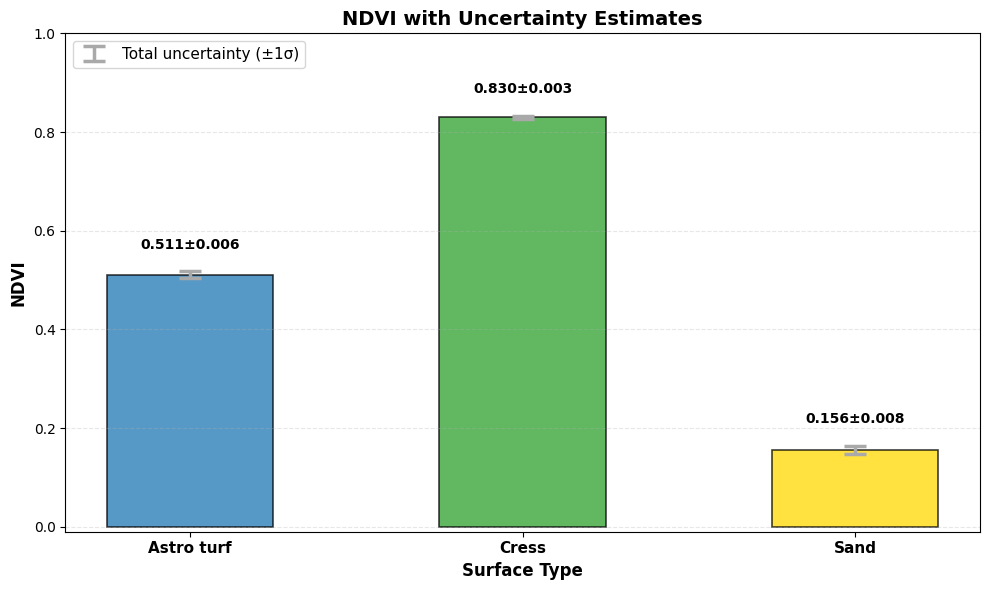


SUMMARY: NDVI Values and Uncertainties Across Surfaces
Surface         NDVI         Random Unc.        Systematic Unc.    Total Unc.  
-------------------------------------------------------------------------------------
Astro turf      0.5112       ±0.0024            ±0.0060            ±0.0065     
Cress           0.8297       ±0.0015            ±0.0026            ±0.0029     
Sand            0.1559       ±0.0030            ±0.0079            ±0.0085     


In [ ]:
# Create visualization comparing NDVI values with uncertainties

surfaces = ["Astro turf", "Cress", "Sand"]
ndvi_values = [ndvi_astroturf, ndvi_cress, ndvi_sand]
ndvi_uncertainties = [u_total_ndvi_astroturf, u_total_ndvi_cress, u_total_ndvi_sand]
u_random_values = [u_random_ndvi_astroturf, u_random_ndvi_cress, u_random_ndvi_sand]
u_syst_values = [u_syst_ndvi_astroturf, u_syst_ndvi_cress, u_syst_ndvi_sand]

# Create bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(surfaces))
width = 0.5

# Define colors for each surface
bar_colors = [color_map["Astro turf"], color_map["Cress"], color_map["Sand"]]

# Plot NDVI values as bars with surface-specific colors
bars = ax.bar(x_pos, ndvi_values, width, color=bar_colors, alpha=0.75, edgecolor='black', linewidth=1.2)

# Add error bars showing total uncertainty (±1σ)
ax.errorbar(x_pos, ndvi_values, yerr=ndvi_uncertainties, fmt="none", 
            ecolor="darkgray", capsize=8, capthick=2.5, elinewidth=2.5, label="Total uncertainty (±1σ)", zorder=3)

# Customize plot
ax.set_ylabel("NDVI", fontsize=12, fontweight="bold")
ax.set_xlabel("Surface Type", fontsize=12, fontweight="bold")
ax.set_title("NDVI with Uncertainty Estimates", fontsize=14, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(surfaces, fontsize=11, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(axis="y", alpha=0.3, linestyle="--", zorder=0)
ax.set_ylim(-0.01, 1.0)

# Add value labels on bars
for bar, val, unc in zip(bars, ndvi_values, ndvi_uncertainties):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + unc + 0.04,
            f"{val:.3f}±{unc:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*85)
print("SUMMARY: NDVI Values and Uncertainties Across Surfaces")
print("="*85)
print(f"{'Surface':<15} {'NDVI':<12} {'Random Unc.':<18} {'Systematic Unc.':<18} {'Total Unc.':<12}")
print("-"*85)
for surf, ndvi, u_rand, u_sys, u_tot in zip(
    surfaces, ndvi_values, u_random_values, u_syst_values, ndvi_uncertainties
):
    print(f"{surf:<15} {ndvi:<12.4f} ±{u_rand:<17.4f} ±{u_sys:<17.4f} ±{u_tot:<11.4f}")

## *Optional: Extension* — End-to-End Uncertainty Propagation

### Why Combine Steps?

In the workflow above, we propagated uncertainties through three separate steps (calibration → bands → NDVI). An alternative is to **combine all operations into a single measurement function** that directly converts DN to NDVI:

$$\text{DN readings} \rightarrow \text{Reflectance calibration} \rightarrow \text{Band integration} \rightarrow \text{NDVI}$$

### Advantages of the End-to-End Approach

- **Simpler workflow:** One propagation operation instead of three
- **Implicit correlation handling:** All relationships between steps are automatically captured
- **Computational efficiency:** Fewer intermediate calculations for large datasets
- **Cleaner code:** Fewer intermediate variables to manage

### Your Challenge

Write a single measurement function that takes raw DN measurements and returns final NDVI, incorporating all three models from Step 3. Then propagate uncertainties through this combined function in a single operation and compare your results with the step-by-step approach above.

In [ ]:
# TODO: Define your end-to-end measurement function here
# This should combine all three modeling steps into a single function

def end_to_end_ndvi(dn_surface, dn_panel, rho_panel):
    """
    Calculate NDVI from raw spectrometer measurements in one integrated step.

    Combines reflectance calibration, band integration, and NDVI calculation.

    :param dn_surface: surface measurement digital numbers (shape: n_wavelengths)
    :param dn_panel: panel (Spectralon) measurement digital numbers (shape: n_wavelengths)
    :param rho_panel: panel reflectance spectrum (shape: n_wavelengths)
    :returns: Normalized Difference Vegetation Index (NDVI)
    """
    # Step 1: Calculate surface reflectance spectrum
    rho = reflectance_model(dn_surface, dn_panel, rho_panel)
    
    # Step 2: Band integrate to Sentinel-2 bands
    rho_red, rho_nir = band_integrate(rho, wavelength)
    
    # Step 3: Calculate NDVI
    ndvi = ndvi_model(rho_red, rho_nir)
    
    return ndvi

In [ ]:
# TODO: Propagate uncertainties through the end-to-end NDVI function
# Compare results with the step-by-step approach used above

# Hints:
# 1. Which inputs have uncertainties? (DN measurements and panel reflectance)
# 2. Should you use propagate_random, propagate_systematic, or both?
# 3. Remember that uncertainties on inputs are already calculated earlier

# Example structure:
# u_random_ndvi_e2e = prop.propagate_random(
#     end_to_end_ndvi,
#     [dn_astroturf_mean, dn_panel_mean, rho_panel],
#     [dn_astroturf_std, dn_panel_std, None]
# )
#
# u_syst_ndvi_e2e = prop.propagate_systematic(
#     end_to_end_ndvi,
#     [dn_astroturf_mean, dn_panel_mean, rho_panel],
#     [None, None, u_rho_panel]
# )

# TODO: Implement uncertainty propagation for each surface
# (or all surfaces at once using loops)

# After propagation, compare:
# - Does end-to-end propagation give the same results as step-by-step?
# - Why or why not?
# - Which approach is simpler? Which is more computationally efficient?

print("Exercise: Implement uncertainty propagation and compare approaches!")

Exercise: Implement uncertainty propagation and compare approaches!
